# Project 2 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the Cats and Dogs data set (and maybe a subset of the MNIST data set).

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

In [2]:
# In the last project we have already seen example of the MNIST data set. Here we take a look at Cats and Dogs

import pandas as pd 

PATHIM = "data//cnd_small//images.csv" 
PATHLB = "data//cnd_small//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

FileNotFoundError: [Errno 2] No such file or directory: 'data//cnd_small//images.csv'

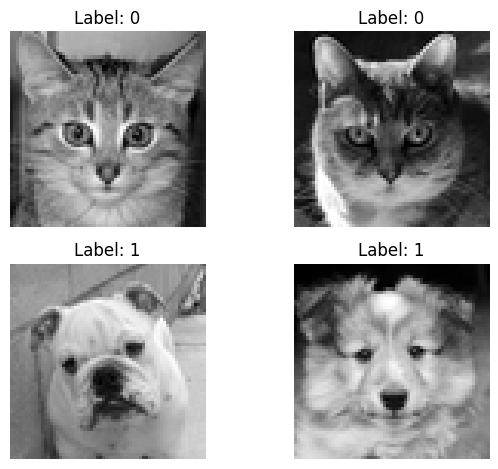

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [ ]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = images
y = labels

# Fixed train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n_train_full = X_train_full.shape[0]
fractions = np.linspace(1.0, 0.1, 10)

results = { "svd": [], "shrink": [] }
rng = np.random.RandomState(0)

for f in fractions:
    n_keep = int(n_train_full * f)
    idx = rng.choice(n_train_full, n_keep, replace=False)
    X_train = X_train_full[idx]
    y_train = y_train_full[idx]

    # SVD solver (fastest)
    try:
        acc_svd = accuracy_score(y_test,
            LinearDiscriminantAnalysis(solver="svd").fit(X_train, y_train).predict(X_test)
        )
    except:
        acc_svd = np.nan

    # Regularized / shrunk LDA (fast, avoids singularity)
    try:
        acc_shrink = accuracy_score(y_test,
            LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
            .fit(X_train, y_train)
            .predict(X_test)
        )
    except:
        acc_shrink = np.nan

    results["svd"].append((f, acc_svd))
    results["shrink"].append((f, acc_shrink))

# Print
for name in results:
    print(f"\n== {name} ==")
    for f, acc in results[name]:
        print(f"Fraction {f:.2f}: acc = {acc:.3f}")


== svd ==
Fraction 1.00: acc = 0.707
Fraction 0.90: acc = 0.715
Fraction 0.80: acc = 0.712
Fraction 0.70: acc = 0.715
Fraction 0.60: acc = 0.760
Fraction 0.50: acc = 0.760
Fraction 0.40: acc = 0.783
Fraction 0.30: acc = 0.755
Fraction 0.20: acc = 0.767
Fraction 0.10: acc = 0.742

== shrink ==
Fraction 1.00: acc = 0.727
Fraction 0.90: acc = 0.738
Fraction 0.80: acc = 0.735
Fraction 0.70: acc = 0.718
Fraction 0.60: acc = 0.723
Fraction 0.50: acc = 0.733
Fraction 0.40: acc = 0.755
Fraction 0.30: acc = 0.735
Fraction 0.20: acc = 0.723
Fraction 0.10: acc = 0.723


# Part 1

*Everyone should do this task.*

For the first part, use the provided Cats and Dogs data set.

Use at least 3 different classifiers and at least 2 feature selection methods.

For example, you can use filtering or wrappers in conjuction with any of the classifiers (using e.g. threshholds on the importance, t-tests/F-tests or CV-error with forward selection etc). I.e., for the filtering method you choose a test or scoring mechanism and use CV to determine the optimal threshold.

For the wrapper method you choose, e.g., forward selection or backward selection, CV is used when to stop adding features. Here, the scoring mechanism to decide which order to drop/add features can be based on drop/increase in predictive performance, importance metrics, etc.

The embedding methods we have talked about in class is lasso/elastic net which is used with multinomial/logistic regression. For the embedding methods, CV is used to choose the penalty parameter.

Note, you can also use a combination of techniques - perhaps you want to filter the features before you use wrappers or embedding methods?

Questions to answer

1. Using CV, determine how many features (pixels) you need for classification. Does the optimal number of features differ between the approaches?

2. Which pixels are selected? Does this differ between the approaches/classification methods? (Can you think of why?)

3. Repeat the above a few times - is the selection stable? (meaning the number of features needed and/or which pixels are chosen is roughly the same across multiple runs).



## Import packages

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV


## Load the data

In [3]:
PATHIM = "C://Users//wwide//MVE441//cnd_large//images.csv" 
PATHLB = "C://Users//wwide//MVE441//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


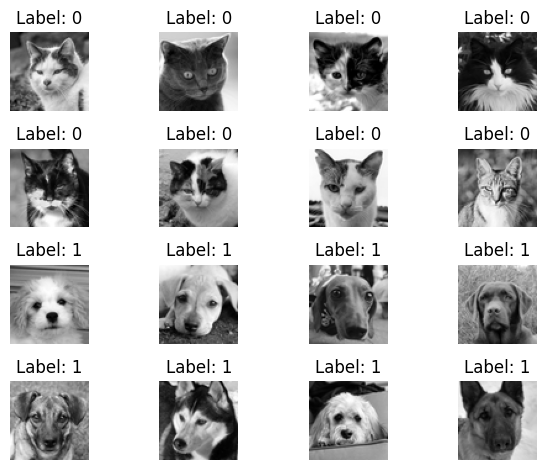

In [4]:
images = np.array(images)
labels = np.array(labels).ravel()

#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 8

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(4, 4)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

## Train/test + 10 fold CV

In [5]:
X = images
y = labels

# Fixed train/test split
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, y, test_size=0.2,  stratify=y, shuffle=True)

# 10 folds CV
size_of_folds = len(X_train_full) // 10
X_folds = []
Y_folds = []

for i in range(10):
    X_folds.append(X_train_full[i*size_of_folds:size_of_folds*(i+1)])
    Y_folds.append(Y_train_full[i*size_of_folds:size_of_folds*(i+1)])
  
X_folds = np.array(X_folds)
Y_folds = np.array(Y_folds)

## Feature selection

### RandomForestClassifier

Fold 1 - Random Forest Accuracy: 0.8688
Fold 2 - Random Forest Accuracy: 0.8612
Fold 3 - Random Forest Accuracy: 0.8588
Fold 4 - Random Forest Accuracy: 0.8838
Fold 5 - Random Forest Accuracy: 0.8562
Fold 6 - Random Forest Accuracy: 0.8725
Fold 7 - Random Forest Accuracy: 0.8400
Fold 8 - Random Forest Accuracy: 0.8775
Fold 9 - Random Forest Accuracy: 0.8762
Fold 10 - Random Forest Accuracy: 0.8812
Random Forest Mean Accuracy: 0.8676 with top 600 features


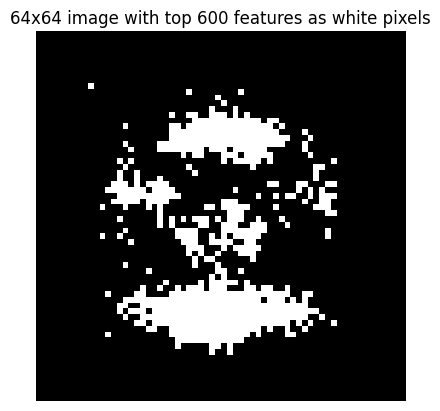

In [6]:
num_feature_list = [600]#, 700, 800, 900, 1000] # [200, 300, 400, 500, 600] # Change for more / less features

selected_features_rf = []
for k in (num_feature_list):
    accuracy_scores = []
    selected_features_n_pxiels = []
    for i in range(10): # Go through each fold and choose fold i as validation (10%)
        X_val = X_folds[i]
        Y_val = Y_folds[i]

        X_train = []
        Y_train = []
        for j in range(10): # Go through each fold and choose j as training (90%)
            if j != i:
                X_train.append(X_folds[j])
                Y_train.append(Y_folds[j])
        X_train = np.concatenate(X_train) # concatenate arrays -> combine the rest into one array
        Y_train = np.concatenate(Y_train)

        # Feature selection with Random Forest, after this repeat the rf_model but only use
        # selected features, and see if the accuracy improves. 
        
        # Select top 200 features
        rf_selector = RandomForestClassifier(random_state=123)
        rf_selector.fit(X_train, Y_train)
        importances = rf_selector.feature_importances_
        sorted_index = np.argsort(importances)[::-1]
        top_features = sorted_index[:k] # Change for more / less features
        selected_features_n_pxiels.append(top_features)

        # Keep only selected features
        X_train_selected = X_train[:, top_features]
        X_val_selected = X_val[:, top_features]

        rf_model = RandomForestClassifier(random_state=123)
        rf_model.fit(X_train_selected, Y_train) # change to selected later

        # Predictions 
        rf_preds = rf_model.predict(X_val_selected) # same here, change to selected later
        accuracy_rf = accuracy_score(Y_val, rf_preds)
        accuracy_scores.append(accuracy_rf)
        print(f"Fold {i+1} - Random Forest Accuracy: {accuracy_rf:.4f}")
    selected_features_rf.append(selected_features_n_pxiels)
    print(f"Random Forest Mean Accuracy: {np.mean(accuracy_scores):.4f} with top {k} features")
    
    # Visualisation of most important features
    # NOTE: Check if we can use gradiant instead of black and white. 
    # NOTE: Would be more informative which features are "more important"
    image_size = (64, 64)
    image = np.zeros(image_size)

    # Chosen features from feature selection
    white_pixel_indices = top_features 

    # The chosen features (pixels) as white the rest as black
    for index in white_pixel_indices:
        row = index // image_size[1]
        col = index % image_size[1]
        image[row, col] = 1.0

    plt.imshow(image, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f"64x64 image with top {k} features as white pixels")
    plt.show()



from collections import Counter

most_important_features=[]
for i in range(len(selected_features_rf)):

    all_important_pixels = np.concatenate((selected_features_rf[i][0],selected_features_rf[i][1], selected_features_rf[i][2],
                                           selected_features_rf[i][3], selected_features_rf[i][4], selected_features_rf[i][5], 
                                           selected_features_rf[i][6], selected_features_rf[i][7], selected_features_rf[i][8], 
                                           selected_features_rf[i][9])) #detta blir en lista med alla top för alla tio runs
 
    nr_pixels_to_choose = num_feature_list[i]

    counts = Counter(all_important_pixels)
    most_common_and_frequensy = counts.most_common(nr_pixels_to_choose)
    most_common_of_all_runns = [int(item[0]) for item in most_common_and_frequensy]
    most_important_features.append(most_common_of_all_runns)

### Forward / backward selection

###  Lasso regression

In [7]:
X = images
y = labels

# Fixed train/test split
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, y, test_size=0.2,  stratify=y, shuffle=True)

X_mean = X_train_full.mean()
X_std = X_train_full.std()
X_scaled = (X_train_full-X_mean)/X_std
# 10 folds CV
size_of_folds = len(X_scaled) // 10
X_folds = []
Y_folds = []

for i in range(10):
    X_folds.append(X_scaled[i*size_of_folds:size_of_folds*(i+1)])
    Y_folds.append(Y_train_full[i*size_of_folds:size_of_folds*(i+1)])
  
X_folds = np.array(X_folds)
Y_folds = np.array(Y_folds)

In [8]:
lasso_path = Lasso(max_iter=10000)
alphas = np.logspace(-3, 2, 100)

lasso_coef_paths = []

for alpha in alphas:
    lasso_path.set_params(alpha=alpha)
    lasso_path.fit(X_scaled, Y_train_full)
    lasso_coef_paths.append(lasso_path.coef_.copy())

lasso_coef_paths = np.array(lasso_coef_paths)  # shape: (n_alphas, p)

KeyboardInterrupt: 

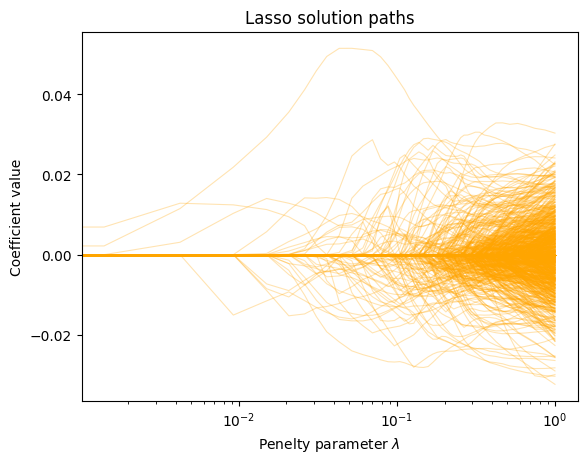

In [ ]:
l1_lasso = np.sum(np.abs(lasso_coef_paths), axis = 1)
max_lasso = np.max(l1_lasso)

l1_lasso_scaled = l1_lasso/max_lasso


plt.plot(l1_lasso_scaled, lasso_coef_paths, alpha = 0.3, linewidth = 0.8, color = 'orange')
plt.xscale('log')
plt.xlabel('Penelty parameter $\lambda$')
plt.ylabel('Coefficient value')
plt.title('Lasso solution paths')
plt.show()

GridSearch to find the best parameter value of C

In [ ]:
X_train = np.concatenate(X_folds)
Y_train = np.concatenate(Y_folds)

params = {"C":np.logspace(-4, 2, 100)}

lasso = LogisticRegression(l1_ratio=1.0, solver='liblinear', max_iter=10000)

lasso_cv=GridSearchCV(lasso, param_grid=params, n_jobs=-1)
lasso_cv.fit(X_train, Y_train)
print("Best Params (1/$\lambda$) {}".format(lasso_cv.best_params_))

Full run with Lasso regression using hyperparameters found using GridSearch.

In [ ]:
# Find best features with Lasso using the best hyperparameters from grid search
k = 200
accuracy_scores = []
for i in range(10): # Go through each fold and choose fold i as validation (10%)
    X_val = X_folds[i]
    Y_val = Y_folds[i]

    X_train = []
    Y_train = []
    for j in range(10): # Go through each fold and choose j as training (90%)
        if j != i:
            X_train.append(X_folds[j])
            Y_train.append(Y_folds[j])
    X_train = np.concatenate(X_train)
    Y_train = np.concatenate(Y_train)
    
    # Select top 200 features
    lasso_selector = LogisticRegression(l1_ratio=1, solver='liblinear', C=0.06, max_iter=10000)
    lasso_selector.fit(X_train, Y_train)
    coefficients = lasso_selector.coef_[0]
    sorted_index = np.argsort(np.abs(coefficients))[::-1]
    top_features = sorted_index[:k] # Change for more / less features

    # Keep only selected features
    X_train_selected = X_train[:, top_features]
    X_val_selected = X_val[:, top_features]

    lasso_model = LogisticRegression(
        l1_ratio=1, solver='liblinear', max_iter=10000, C=0.06, random_state=42)
    lasso_model.fit(X_train_selected, Y_train) # change to selected later

    # Predictions 
    lasso_preds = lasso_model.predict(X_val_selected) # same here, change to selected later
    accuracy_lasso = accuracy_score(Y_val, lasso_preds)
    accuracy_scores.append(accuracy_lasso)
    print(f"Fold {i+1} - Lasso Accuracy: {accuracy_lasso:.4f}")

print(f"Lasso Mean Accuracy: {np.mean(accuracy_scores):.4f} with top {k} features")

Combine selections?? Maybe use RandomForest first and select 500 features and then have forward/backward selection and see which are the best of the best? If we have time.

## Classification using the selected features

### Classification method 1 RandomForest

Lasso used as a feature selector and RandomForest used to classify

In [ ]:
k = 225
accuracy_scores = []
print(f'Lasso using {k} features')

for i in range(10): 
    X_val = X_folds[i]
    Y_val = Y_folds[i]

    X_train = []
    Y_train = []
    for j in range(10): 
        if j != i:
            X_train.append(X_folds[j])
            Y_train.append(Y_folds[j])
    X_train = np.concatenate(X_train)
    Y_train = np.concatenate(Y_train)
    
    # Select top 200 features
    lasso_selector = LogisticRegression(l1_ratio=1, solver='liblinear', C=0.06, max_iter=10000)
    lasso_selector.fit(X_train, Y_train)
    coefficients = lasso_selector.coef_[0]
    sorted_index = np.argsort(np.abs(coefficients))[::-1]
    top_features = sorted_index[:k] # Change k for more / less features

    # Keep only selected features
    X_train_selected = X_train[:, top_features]
    X_val_selected = X_val[:, top_features]

    lasso_forest_model = RandomForestClassifier() # Add hyperparameters (GridSearch??)
    lasso_forest_model.fit(X_train_selected, Y_train)

    # Predictions 
    lasso_preds = lasso_forest_model.predict(X_val_selected)
    accuracy_lasso_forest = accuracy_score(Y_val, lasso_preds)
    accuracy_scores.append(accuracy_lasso_forest)
    print(f"Fold {i+1}, accuracy = {accuracy_lasso_forest}")

print(f"Random Forest Accuracy: {np.mean(accuracy_scores):.4f} with top {k} features from Lasso")

### Classification method 2 logistic regresion

In [ ]:
from sklearn.linear_model import LogisticRegression
for i in range(len(selected_features_rf)):
    best_pixels = most_important_features[i] 

    X_train_logreg = X_train_full[:, best_pixels]
    X_test_final = X_test[:, best_pixels]

    log_reg = LogisticRegression(random_state=123, max_iter=5000, solver="lbfgs")
    log_reg.fit(X_train_logreg, Y_train_full) 
    preds_log_reg = log_reg.predict(X_test_final)
    
    accuracy_log_reg = accuracy_score(Y_test, preds_log_reg)
    #f1_log_reg = f1_score(Y_test, preds_log_reg, average="weighted")

    print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
    #print(f"Logistic Regression F1 Score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.7880


### Classification method 3 CART

In [11]:
# CART
from sklearn.tree import DecisionTreeClassifier, plot_tree
for i in range(len(selected_features_rf)):
    best_pixels = most_important_features[i] 

    X_train_cart = X_train_full[:, best_pixels]
    X_test_cart = X_test[:, best_pixels]

    cart_model = DecisionTreeClassifier(
        random_state=123,
        max_depth=10,
        min_samples_split=15,
        min_samples_leaf=60,
        splitter="best",
        criterion="entropy"
    )
    cart_model.fit(X_train_cart, Y_train_full)

    # Prediction
    preds_cart = cart_model.predict(X_test_cart)
    accuracy_cart = accuracy_score(Y_test, preds_cart)
    #cross_val_scores = cross_val_score(cart_model, X_train_cart, y_train, cv=5)
    #f1 = f1_score(y_val, preds_cart, average="weighted")

    print(f"Tree depth: {cart_model.get_depth()}")
    print(f"Number of leaves: {cart_model.get_n_leaves()}")
    print(f"Accuracy: {accuracy_cart:.4f}")
    #print(f"Cross-validation scores: {cross_val_scores.mean()}")
    #print(f"F1 Score: {f1:.4f}")

Tree depth: 10
Number of leaves: 81
Accuracy: 0.7485


## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Correlated noise features
Use the Cats and Dogs data set. 

Add (independent) Gaussian noise to a subset of the features. Increase the percentage of the features. 
How is classification accuracy affected for the different methods?

Now, do the same but with correlated Gaussian noise. 
How do the different methods handle correlated noise features? 
At what noise level do the methods break down? 

### Theme 2 - Image flip
Use the Cats and Dogs data set. 

Flip half of the images (half of the cats and half of the dogs) upside down. 
Perform the same steps as in Part 1. 

How is feature importance affected by the flipping?

### Theme 3 - Heterogeneous classes
Use the MNIST data set. 

Create heterogeneous classes by flipping half of the images in a class. 
1. First, flip images in class 0.
2. Then, flip images in class 4 (and revert the changes from the previous step).
3. Lastly, flip images in one of class 2, 5, 6 or 9 (and revert the changes from the previous step).

Perform the same steps as in Part 1 for the three sets. 

Present confusion matrices and other appropriate plots. What happened? 